# Silver nanoparticles → AnnData

Silver nanoparticle exposure ([`cpg0040`](https://broadinstitute.github.io/cellpainting-gallery/)), varying particle size, concentration and exposure time. Small, but the design covariates are exactly what a morphological profile should respond to.

One observation is a well, one variable is a CellProfiler feature.
Well-level profiles only, no images:

```bash
aws s3 cp --no-sign-request --recursive --exclude "*" --include "*_normalized_feature_select_batch.csv.gz" \
  s3://cellpainting-gallery/cpg0040-garcia-fossa-AgNP/unicamp/workspace/profiles/ .
```

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import scanpy as sc

import cell_painting_io as cpio

PROFILES = Path("~/data/cpg0040-garcia-fossa-AgNP/profiles").expanduser()

In [2]:
files = sorted(PROFILES.glob("*/*/*.csv.gz"))
print(f"{len(files)} plates")

4 plates


In [3]:
adata = cpio.read_profiles(
    files, index_columns=["batch", "Plate", "Well"], path_columns={"batch": 2}, on_column_mismatch="intersect"
)
adata

/home/lheumos/code/cell-painting-io/cell_painting_io.py:58: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame[name] = path.parents[depth - 1].name
/home/lheumos/code/cell-painting-io/cell_painting_io.py:58: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame[name] = path.parents[depth - 1].name
/home/lheumos/code/cell-painting-io/cell_painting_io.py:58: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns 

AnnData object with n_obs × n_vars = 180 × 112
    obs: 'plate_map_name', 'Compound', 'NPSize_nm', 'Cell', 'Time', 'Concentration_mgml', 'control_type', 'Plate', 'Well', 'Site_Count', 'Object_Count', 'batch'
    layers: None (.X)

In [4]:
cpio.annotate_features(adata.var)
adata = cpio.drop_incomplete_features(adata)
adata = cpio.drop_extreme_features(adata)
adata = cpio.drop_constant_features(adata)


def present(columns):
    return [c for c in columns if c in adata.obs.columns and adata.obs[c].nunique() > 1]


cpio.categorize(adata, present(["Plate", "Compound", "NPSize_nm", "Time", "Concentration_mgml", "batch"]))
adata.var

,compartment,family,channel,channel_2,n_channels
feature,,,,,
Cells_AreaShape_CentralMoment_0_1,cells,areashape,NaN,NaN,0
Cells_AreaShape_CentralMoment_1_0,cells,areashape,NaN,NaN,0
Cells_AreaShape_CentralMoment_1_2,cells,areashape,NaN,NaN,0
Cells_AreaShape_CentralMoment_2_1,cells,areashape,NaN,NaN,0
Cells_AreaShape_Compactness,cells,areashape,NaN,NaN,0
...,...,...,...,...,...
Nuclei_AreaShape_Zernike_9_1,nuclei,areashape,NaN,NaN,0
Nuclei_AreaShape_Zernike_9_3,nuclei,areashape,NaN,NaN,0
Nuclei_AreaShape_Zernike_9_5,nuclei,areashape,NaN,NaN,0


## Sanity checks

In [5]:
print(f"{adata.n_obs:,} wells x {adata.n_vars:,} features")
print(f"non-finite: {int((~np.isfinite(adata.X)).sum())} | max|x|: {np.abs(adata.X).max():.1f}")
for column in present(["Compound", "NPSize_nm", "Concentration_mgml"]):
    print(f"\n{column}:")
    print(adata.obs[column].value_counts(dropna=False).head(6).to_string())

180 wells x 112 features
non-finite: 0 | max|x|: 371.2

Compound:
Compound
AgNP           120
Non-treated     60

NPSize_nm:
NPSize_nm
0      60
40     60
100    60

Concentration_mgml:
Concentration_mgml
0.00000    60
0.00012    60
0.00036    60


In [6]:
adata.write_h5ad(PROFILES.parent / "garcia_fossa_agnp.h5ad")

## UMAP

The profiles are already normalized, so they enter PCA unscaled.

In [7]:
sc.pp.pca(adata, n_comps=min(50, adata.n_vars - 1))
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


How often do neighbouring wells share a label, against the rate expected if labels were shuffled?
Above 1 means the covariate explains part of the embedding.

In [8]:
cpio.neighbour_enrichment(adata, present(["Plate", "Compound", "NPSize_nm", "Concentration_mgml", "Time"]))

,observed,baseline,ratio
covariate,,,
Plate,0.276,0.250,1.105
Compound,0.591,0.556,1.064
NPSize_nm,0.339,0.333,1.018
Concentration_mgml,0.339,0.333,1.018
Time,0.567,0.333,1.700


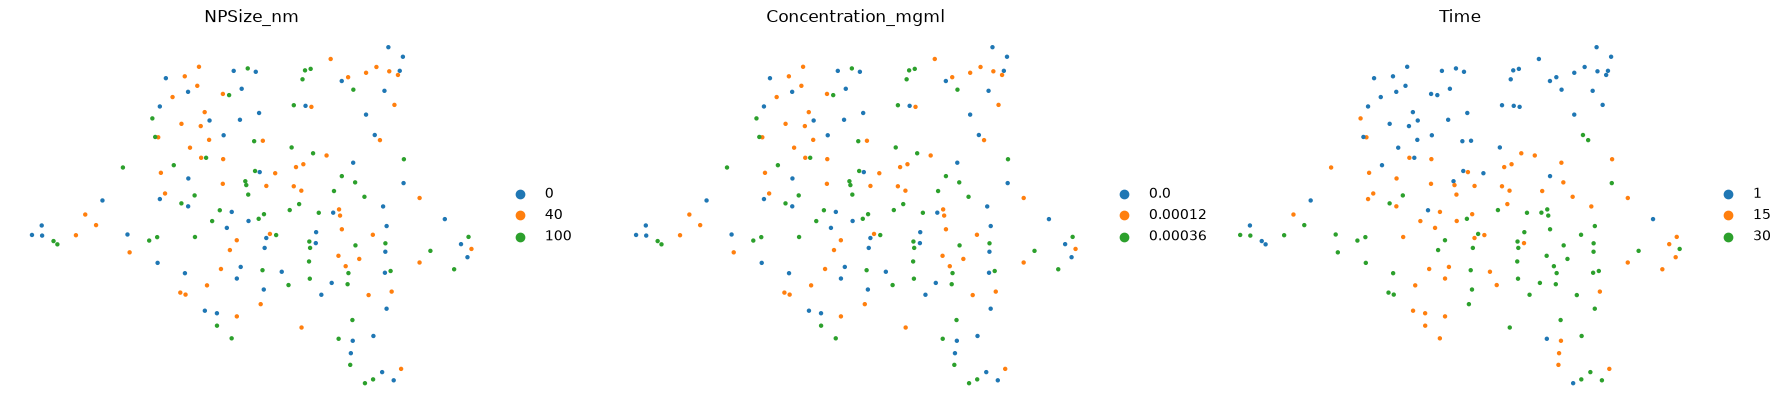

In [9]:
sc.pl.umap(adata, color=present(["NPSize_nm", "Concentration_mgml", "Time"])[:3], ncols=3, frameon=False, size=40)